# Statistics basics 🧮

## What you will learn in this course 🧐🧐

Every business decision based on data starts with a single question: *what is a typical value?* Before you can predict customer churn, forecast revenue, or detect fraud, you must summarize your data with a few numbers that describe its center and its spread. This lecture gives you those tools.

By the end of this lecture, you will be able to:
- Define a random variable $X$ and connect it to a real business measurement.
- Compute the mean, median, and mode using their formal mathematical definitions.
- Identify the right statistic for symmetric data, skewed data, and categorical data.
- Calculate the variance and standard deviation step by step from their definitions.
- Interpret the spread of a dataset and use it for outlier detection.
- Visualize distributions with seaborn to confirm what the numbers say.

<Note type="important" title="Focus on understanding the concepts"> 

Plots are there to help you visualize the concepts. Do not focus on the code to create the plots, but rather on what the plots are showing you about the relationships between variables. We do not expect you to be able to write the code to create the plots, but we do expect you to understand what the plots are showing you about the relationships between variables.

</Note>

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean default style for all charts
sns.set_theme(style="whitegrid")

## Business context 

<img src ="https://ai-fullstack-assets.s3.eu-west-3.amazonaws.com/M02-EDA/pulse_social_logo.png" /> 

We work with a fictional company called **PulseSocial**, a social media analytics platform. PulseSocial collects data on user sessions, post engagement, subscription tiers, and more. You are a junior data analyst on their team. Throughout this lecture, you will compute statistics on real-looking PulseSocial data and learn when each statistic is the right tool.

## What is a random variable?

Before we define any statistic, we need one piece of vocabulary: the **random variable**.

A **random variable**, written as $X$, is a variable whose value is the result of a random measurement or observation. It is not a fixed number. Instead, it is a placeholder for *the value we will get when we measure something*.

In business, a random variable is just any **measurable quantity that varies across observations**. Some examples from PulseSocial:

- $X$ = the number of minutes a user spends on the platform per day.
- $X$ = the number of likes a post receives in its first hour.
- $X$ = the subscription plan a new user picks.
- $X$ = the amount in euros a customer spends per month.

When we collect data, we observe many values of $X$. We write these values as $x_1, x_2, x_3, \ldots, x_n$ where $n$ is the total number of observations. The lowercase $x_i$ refers to the i-th specific value we measured. The uppercase $X$ is the abstract concept itself.

> The random variable $X$ is the **question**. The values $x_1, x_2, \ldots, x_n$ are the **answers** we collected from real users.



## The mean

Let $X$ be the random variable representing **daily session time in minutes per user**. We collect $n$ observations: $x_1, x_2, x_3, \ldots, x_n$ where each $x_i$ is the session time of one specific user.

The **arithmetic mean**, also called the **average** or **sample mean**, is defined as:

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + x_3 + \ldots + x_n}{n}$$

In plain words: add all observed values, then divide by the count $n$. The symbol $\bar{x}$ (read as **"x-bar"**) is the standard notation for the sample mean.

The next code block computes the mean of daily session times for 9 PulseSocial users. 


In [2]:
# 9 PulseSocial users, daily session time in minutes
# Each value is one observation x_i of the random variable X
session_times = np.array([18, 22, 25, 27, 30, 32, 35, 40, 45])

mean_numpy = session_times.mean()
print(f"Mean (x-bar) from NumPy:       {mean_numpy:.2f}")


Mean (x-bar) from NumPy:       30.44


The mean is **about 30.44 minutes**. The product team now has a single number for the typical session time.


The next chart plots each observation as a dot, with a vertical line marking the mean. We expect the dots to be balanced around the line.


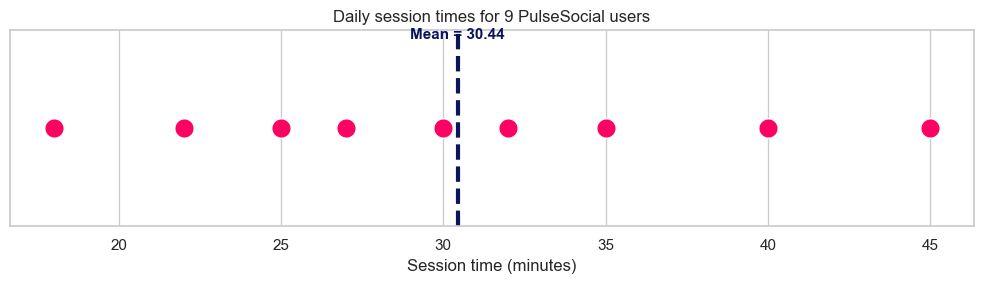

In [3]:
# Create a scatter plot of the observations using seaborn
fig, ax = plt.subplots(figsize=(10, 3))

# Plot each observation as a dot on the same horizontal line
y_values = [1] * len(session_times)
sns.scatterplot(x=session_times, y=y_values, s=200, color="#FE0162", ax=ax)

# Add a vertical dashed line for the mean
ax.axvline(mean_numpy, color="#0B155B", linestyle="--", linewidth=3)
ax.text(mean_numpy, 1.05, f"Mean = {mean_numpy:.2f}",
        color="#0B155B", ha="center", fontsize=11, fontweight="bold")

# Tidy up the chart
ax.set_title("Daily session times for 9 PulseSocial users")
ax.set_xlabel("Session time (minutes)")
ax.set_yticks([])
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Why the mean can mislead

Now imagine PulseSocial has a **power user**. This user is logged in all day for work and accumulates 480 minutes (8 hours) of session time. The other 9 users still average around 30 minutes. We add the power user to the dataset and recompute the mean.


In [4]:
# Original 9 users plus 1 power user with 480 minutes
power_user_time = 480
session_times_with_power = np.append(session_times, power_user_time)

# Recompute the mean
n_new = len(session_times_with_power)
mean_with_power = session_times_with_power.mean()

print(f"Original mean (9 users):       {mean_numpy:.2f} minutes")
print(f"New mean (10 users):           {mean_with_power:.2f} minutes")
print(f"Increase from one outlier:     {mean_with_power - mean_numpy:.2f} minutes")
print(f"Percentage change:             {(mean_with_power - mean_numpy) / mean_numpy * 100:.1f}%")

Original mean (9 users):       30.44 minutes
New mean (10 users):           75.40 minutes
Increase from one outlier:     44.96 minutes
Percentage change:             147.7%


Look at the result. Adding **one** outlier raised the mean from about 30 to about 75 minutes. That is a **150% increase**. None of the original 9 users have anything close to 75 minutes of session time. **The mean no longer describes a typical user**. 

<Note type="warning">

When your data contains outliers or is heavily skewed, the mean can be **misleading**. A famous example: if Jeff Bezos walks into a bar with 9 other customers, the **average net worth in the bar** instantly jumps into the billions. But the **typical customer** in that bar is still poor. Always check for outliers before trusting the mean.

</Note>


## The median

Let $X$ be a random variable and let $x_1, x_2, \ldots, x_n$ be $n$ observed values. To compute the median, we first sort the values from smallest to largest:

$$x_{(1)} \leq x_{(2)} \leq x_{(3)} \leq \ldots \leq x_{(n)}$$

The notation $x_{(i)}$ (with parentheses around $i$) means the i-th value **after sorting**. The **median** $\tilde{x}$ is then defined as:

$$\tilde{x} = \begin{cases} x_{\left(\frac{n+1}{2}\right)} & \text{if } n \text{ is odd} \\ \frac{1}{2}\left( x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)} \right) & \text{if } n \text{ is even} \end{cases}$$

In plain words:
- If $n$ is **odd**, the median is the value in the exact middle.
- If $n$ is **even**, the median is the **average of the two middle values**.

The median has one defining property: **exactly half of the observations are less than or equal to it, and exactly half are greater than or equal to it**. The median splits the data into two equal halves.

<Note type="important" title ="Mean vs Median">
The median is **robust to outliers**. A single extreme value cannot pull it far from the typical experience. This is why income, house prices, response times, and engagement metrics are almost always reported as medians.
</Note>

The next code block computes the median for two cases: an odd count ($n=9$) and an even count ($n=10$). Then we apply the median to our power user dataset and compare with the mean.

In [5]:
# Case 1: odd count (n = 9)
session_times = np.array([18, 22, 25, 27, 30, 32, 35, 40, 45])

# For n=9 (odd), the median is at position (n+1)/2 = 5, which is index 4
median_numpy = np.median(session_times)
print(f"Median (NumPy):   {median_numpy}")
print()

# Case 2: even count (n = 10) — add the power user
session_times_with_power = np.append(session_times, 480)
median_numpy_even = np.median(session_times_with_power)
print(f"Median (NumPy):   {median_numpy_even}")


Median (NumPy):   30.0

Median (NumPy):   31.0


In [6]:
# Compare mean vs median on the dataset with the power user outlier
mean_with_power = session_times_with_power.mean()
median_with_power = np.median(session_times_with_power)

print(f"Dataset includes 9 normal users + 1 power user (480 min)")
print(f"  Mean:   {mean_with_power:.2f} minutes")
print(f"  Median: {median_with_power:.2f} minutes")
print(f"  Difference: {mean_with_power - median_with_power:.2f} minutes")
print()
print("The median barely moved when we added the outlier.")
print("The mean exploded.")


Dataset includes 9 normal users + 1 power user (480 min)
  Mean:   75.40 minutes
  Median: 31.00 minutes
  Difference: 44.40 minutes

The median barely moved when we added the outlier.
The mean exploded.


The median sits at 31 minutes. The mean sits at about 75 minutes. The median is the **honest** description of a typical user. The mean has been hijacked by a single outlier.

<Note type="important">

In business reports, **always compute both mean and median**. If they differ by more than 10 to 20 percent, your data is **skewed**. The gap between mean and median is the **fingerprint of skew**. When you see this gap, switch to the median for the typical case, or report both values with a note explaining the difference.

</Note>

The next chart shows the same data with both the mean and the median marked. The visual gap between the two lines is the most useful sign of an outlier in your data.

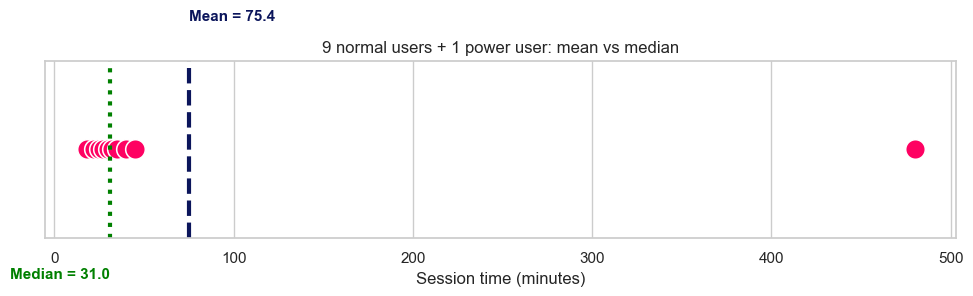

In [7]:
# Build a scatter plot with both mean and median lines
fig, ax = plt.subplots(figsize=(10, 3.5))

# Add the 10 observations as dots on the same horizontal line
y_values = [1] * len(session_times_with_power)
sns.scatterplot(x=session_times_with_power, y=y_values, s=200,
                color="#FE0162", ax=ax)

# Add a dashed line for the mean
ax.axvline(mean_with_power, color="#0B155B", linestyle="--", linewidth=3)
ax.text(mean_with_power, 1.08, f"Mean = {mean_with_power:.1f}",
        color="#0B155B", ha="left", fontsize=11, fontweight="bold")

# Add a dotted line for the median
ax.axvline(median_with_power, color="green", linestyle=":", linewidth=3)
ax.text(median_with_power, 0.92, f"Median = {median_with_power:.1f}",
        color="green", ha="right", fontsize=11, fontweight="bold")

# Tidy up the chart
ax.set_title("9 normal users + 1 power user: mean vs median")
ax.set_xlabel("Session time (minutes)")
ax.set_yticks([])
ax.set_ylabel("")

plt.tight_layout()
plt.show()

## The mode

Let $X$ be a random variable that can take values in some set, and let $x_1, x_2, \ldots, x_n$ be $n$ observed values. The **mode** is the value (or values) that appear **most frequently** in the data.

Formally, define the count function $f(v)$ as:

$$f(v) = \sum_{i=1}^{n} \mathbb{1}(x_i = v)$$

Here $\mathbb{1}(\cdot)$ is the **indicator function**. It returns 1 if the condition inside is true, and 0 if it is false. So $f(v)$ counts how many times the value $v$ appears in the data.

The mode is then:

$$\text{Mode}(X) = \arg\max_{v} \, f(v)$$

The notation $\arg\max_{v} f(v)$ means "the value $v$ that makes $f(v)$ as large as possible." In plain words: **the most common value**.

A dataset can have:
- **One mode** (called *unimodal*): one clear winner.
- **Two modes** (called *bimodal*): two values tie for the most frequent. This often signals **two different groups mixed in the same dataset**.
- **No mode**: every value appears the same number of times.

The mode is the only measure of central tendency that works for **categorical data** (text, labels, categories). It also works for numeric data, but is most often used for categories.


The next code block builds a small PulseSocial user dataset with a categorical column (subscription plan) and a numeric column (number of hashtags per post). 

In [8]:
# A small dataset of 10 PulseSocial users
user_data = {
    "subscription_plan": ["Free", "Basic", "Premium", "Basic", "Free",
                          "Basic", "Premium", "Basic", "Free", "Basic"],
    "hashtags_per_post": [3, 5, 5, 7, 5, 5, 2, 5, 4, 5]
}
users_df = pd.DataFrame(user_data)
print("PulseSocial user data:")
print(users_df)


PulseSocial user data:
  subscription_plan  hashtags_per_post
0              Free                  3
1             Basic                  5
2           Premium                  5
3             Basic                  7
4              Free                  5
5             Basic                  5
6           Premium                  2
7             Basic                  5
8              Free                  4
9             Basic                  5


We build a small Pandas DataFrame with 10 users. Each user has two attributes: their subscription plan (a category) and their average hashtags per post (a number). This mimics the kind of mixed-type data that real business systems produce.


In [9]:
# Method 1: scipy.stats.mode for NUMERIC data
hashtag_mode_result = stats.mode(users_df["hashtags_per_post"], keepdims=False)
print(f"Mode of hashtags_per_post: {hashtag_mode_result.mode}")
print(f"It appears {hashtag_mode_result.count} times")

# Method 2: Pandas .mode() method — works for both numeric and categorical
plan_modes = users_df["subscription_plan"].mode()
hashtag_modes = users_df["hashtags_per_post"].mode()
print(f"\nPandas .mode() of subscription_plan: {plan_modes.tolist()}")
print(f"Pandas .mode() of hashtags_per_post:  {hashtag_modes.tolist()}")


Mode of hashtags_per_post: 5
It appears 6 times

Pandas .mode() of subscription_plan: ['Basic']
Pandas .mode() of hashtags_per_post:  [5]


A bar chart is the natural way to display the mode. The tallest bar **is** the mode.


/var/folders/xw/p2_5w_9n347cnj9xmkd62tm40000gn/T/ipykernel_15706/4207941221.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plan_names, y=plan_values, palette=bar_colors, ax=ax)


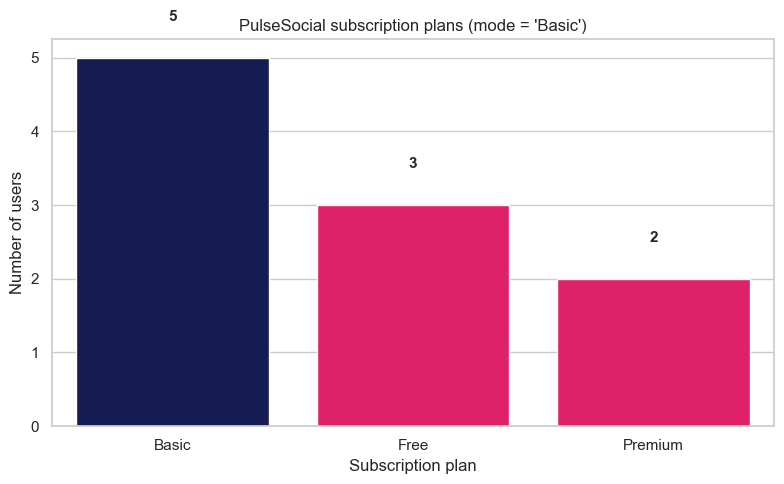

In [10]:
# Build a bar chart of the subscription plan frequencies
plan_counts = users_df["subscription_plan"].value_counts()
most_common_plan = plan_counts.idxmax()  # get the mode category name
plan_names = plan_counts.index.tolist()
plan_values = plan_counts.values.tolist()

# Color the mode in dark blue, the others in pink
bar_colors = []
for name in plan_names:
    if name == most_common_plan:
        bar_colors.append("#0B155B")
    else:
        bar_colors.append("#FE0162")

# Build the chart with seaborn
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=plan_names, y=plan_values, palette=bar_colors, ax=ax)

# Show the count above each bar
for i in range(len(plan_values)):
    count = plan_values[i]
    ax.text(i, count + 0.5, str(count), ha="center", fontsize=11,
            fontweight="bold")

ax.set_title(f"PulseSocial subscription plans (mode = '{most_common_plan}')")
ax.set_xlabel("Subscription plan")
ax.set_ylabel("Number of users")

plt.tight_layout()
plt.show()

We extract the category names with `.index.tolist()` and the counts with `.values.tolist()`. We pass these standard Python lists to seaborn.

We build a list of bar colors with a simple `for` loop. The mode bar gets the dark blue brand color (`#0B155B`). The other bars get pink (`#FE0162`). This visually highlights the answer.

The chart instantly shows that "Basic" wins. It is taller than the other two combined. The product team has their answer with a glance.


## Variance and standard deviation

Mean, median, and mode describe the **center** of your data. But two datasets can have the same mean and look completely different. One can be tightly packed near the mean. The other can be wildly scattered.

We need a second concept: **how spread out is the data?**

Let $X$ be a random variable and $x_1, \ldots, x_n$ its observed values, with mean $\bar{x}$. The **sample variance** is defined as:

$$s^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

In plain words: take each observation, subtract the mean, square the result, then average those squared differences.

Why squared? Because some deviations are positive and some are negative, and they would cancel out if we did not square them. Squaring also penalizes **large** deviations more than small ones. A value 10 units away from the mean contributes 100 to the variance. A value 1 unit away contributes only 1.

The variance has a problem: its units are the **square** of the original units. If your data is in euros, the variance is in **euros squared**, which has no clear meaning.

The fix is the **standard deviation**:

$$s = \sqrt{s^2} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2}$$

The standard deviation is in the **same units** as the original data. If your data is in euros, the standard deviation is in euros. This makes it the most useful spread measure for business reports.

<Note type="important">

The standard deviation, often written as $\sigma$ for a population or $s$ for a sample, is the **second parameter** of every distribution we will study in the next lecture. The Normal distribution has two parameters: $\mu$ (the mean) and $\sigma$ (the standard deviation). Without understanding standard deviation, you cannot interpret distribution shapes, set thresholds, or detect outliers.

</Note>


The next code block computes the variance and standard deviation step by step for two regional teams. Both teams have the same mean satisfaction score, but very different consistency. We do the calculation by hand to make the formula concrete, then with NumPy.


In [11]:
# Two regional teams, each with 5 customer satisfaction scores out of 5
team_north = np.array([4.1, 4.2, 4.2, 4.2, 4.3])  # very consistent
team_south = np.array([2.0, 3.5, 4.2, 5.0, 6.3])  # wildly inconsistent

# Note: team_south has values above 5 to make the spread dramatic for teaching.
# In real customer data, scores would be capped at 5.

print(f"Team North mean: {team_north.mean()}")
print(f"Team South mean: {team_south.mean()}")
print("Both teams have the same mean! But the teams are very different.")
print()
print(f"Team Sud Variance :    {team_south.var()}")
print(f"Team Sud Std:         {team_south.std():.3f}")
print()
# Now Team North
print(f"Team North Variance :    {team_north.var()}")
print(f"Team North Std:         {team_north.std():.3f}")
print("Team North has very low spread. Almost every score is right at the mean.")


Team North mean: 4.2
Team South mean: 4.2
Both teams have the same mean! But the teams are very different.

Team Sud Variance :    2.0759999999999996
Team Sud Std:         1.441

Team North Variance :    0.004000000000000007
Team North Std:         0.063
Team North has very low spread. Almost every score is right at the mean.


The next chart shows both teams as dots, with vertical lines for the mean and shaded regions for the $\pm 1$ standard deviation range. The width of the shaded region is the visual signature of spread.


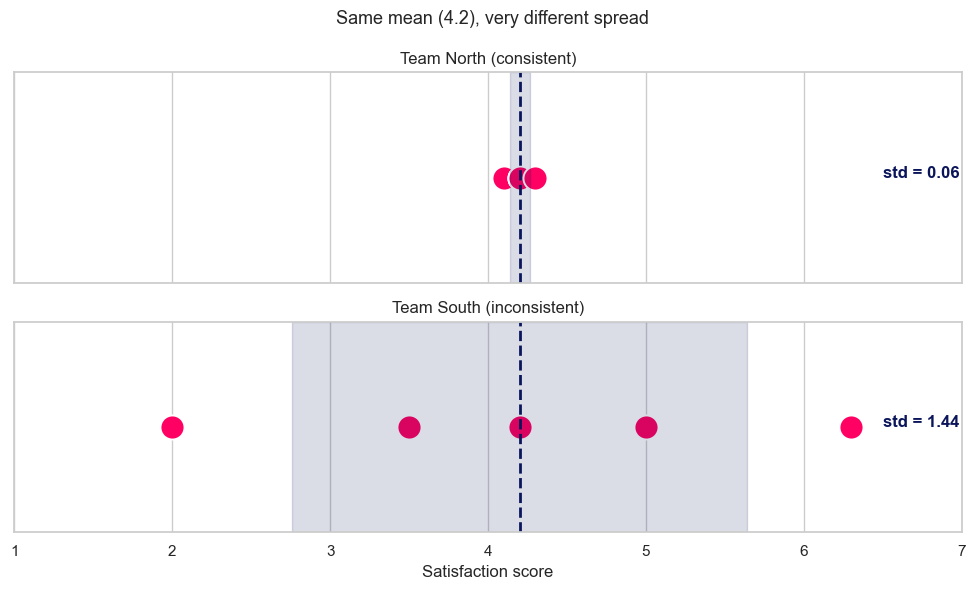

In [12]:
# Build the figure with 2 stacked subplots, one per team
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

# --- Team North subplot ---
mean_north = team_north.mean()
std_north = team_north.std()

ax_n = axes[0]
y_north = [1] * len(team_north)
sns.scatterplot(x=team_north, y=y_north, s=300, color="#FE0162", ax=ax_n)

# Dashed line for the mean
ax_n.axvline(mean_north, color="#0B155B", linestyle="--", linewidth=2)

# Shaded band for one standard deviation around the mean
ax_n.axvspan(mean_north - std_north, mean_north + std_north,
             color="#0B155B", alpha=0.15)

# Annotate with the std value
ax_n.text(6.5, 1.0, f"std = {std_north:.2f}",
          color="#0B155B", fontsize=12, fontweight="bold")

ax_n.set_title("Team North (consistent)")
ax_n.set_yticks([])
ax_n.set_ylabel("")
ax_n.set_xlim(1, 7)

# --- Team South subplot ---
mean_south = team_south.mean()
std_south = team_south.std()

ax_s = axes[1]
y_south = [1] * len(team_south)
sns.scatterplot(x=team_south, y=y_south, s=300, color="#FE0162", ax=ax_s)

# Dashed line for the mean
ax_s.axvline(mean_south, color="#0B155B", linestyle="--", linewidth=2)

# Shaded band for one standard deviation around the mean
ax_s.axvspan(mean_south - std_south, mean_south + std_south,
             color="#0B155B", alpha=0.15)

# Annotate with the std value
ax_s.text(6.5, 1.0, f"std = {std_south:.2f}",
          color="#0B155B", fontsize=12, fontweight="bold")

ax_s.set_title("Team South (inconsistent)")
ax_s.set_yticks([])
ax_s.set_ylabel("")
ax_s.set_xlabel("Satisfaction score")
ax_s.set_xlim(1, 7)

fig.suptitle("Same mean (4.2), very different spread", fontsize=13)
plt.tight_layout()
plt.show()

The plot makes the difference instantly clear.

Team North's dots are tightly packed around the mean. The shaded band is **narrow**. The standard deviation is small.

Team South's dots are scattered across the full range. The shaded band is **wide**. The standard deviation is large.

This is what a manager needs to see. Both teams have the same average score, but Team South is far less reliable. The director should investigate why.

<Note type="info">

In production analytics, the standard deviation drives most quality and outlier rules. Common rule: **flag anything more than 3 standard deviations from the mean as a possible outlier**. We will see why this rule works in the next lecture, when we study the Normal distribution.

</Note>


## Resources 📚📚
- [Mean, median, mode, variance, and standard deviation](https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data) 
- [Elements of Statistical Learning](https://web.stanford.edu/~hastie/ElemStatLearn/) 